# 1.数据预处理与特征工程

In [7]:
import pandas as pd
import numpy as np

# ==================== 1. 读取数据 ====================
file_path = 'all_lmig_data_with_time.parquet'
df = pd.read_parquet(file_path)

print(f"原始数据形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")
print(f"缺失值统计:\n{df.isnull().sum()}")

# ==================== 2. 基础清洗 ====================
# 剔除关键特征为空的样本（可根据实际情况调整）
required_cols = ['Group_Radiance', 'Group_Footprint', 'Group_Event_Count',
                 'Hour', 'Month']
df = df.dropna(subset=required_cols)

# 剔除明显异常值（例如负值或零值，根据物理意义）
df = df[(df['Group_Radiance'] > 0) &
        (df['Group_Footprint'] > 0) &
        (df['Group_Event_Count'] > 0)]

print(f"清洗后数据形状: {df.shape}")

# ==================== 3. 特征工程 ====================
# 3.1 直接可用的风险相关特征
features = pd.DataFrame()
features['radiance'] = df['Group_Radiance']          # 辐射能量
features['footprint'] = df['Group_Footprint']        # 覆盖面积
features['event_count'] = df['Group_Event_Count']    # 事件数量

# 3.2 时间特征（捕捉昼夜与季节影响，降低地域关联）
features['hour'] = df['Hour'] + df['Minute'] / 60    # 0-23
features['month'] = df['Month']                      # 1-12
features['day'] = df['Day']
# features['minute'] = df['Minute']                    # 0-59

# 可选：添加经纬度（若希望保留地理信息，但会引入地域关联；此处保留但注释说明）
# features['longitude'] = df['Group_Longitude']
# features['latitude'] = df['Group_Latitude']

# 3.3 派生特征（可根据文献或物理意义增加）
# 单位面积辐射强度（能量密度）
# features['radiance_density'] = features['radiance'] / (features['footprint'] + 1e-10)

# 平均单次事件的能量（辐射能量 / 事件数）
features['avg_energy_per_event'] = features['radiance'] / (features['event_count'] + 1e-10)

# 平均单次事件的覆盖面积（足迹 / 事件数）
# 该指标无效（全部为100，不再计算）
features['avg_area_per_event'] = features['footprint'] / (features['event_count'] + 1e-10)

# 全局比较标志（与整体分布比较，不引入地域）
global_radiance_75p = features['radiance'].quantile(0.75)
global_footprint_75p = features['footprint'].quantile(0.75)

features['is_high_radiance'] = (features['radiance'] > global_radiance_75p).astype(int)
features['is_large_footprint'] = (features['footprint'] > global_footprint_75p).astype(int)

# 时间特征（白天时间为6-18点，午后时间为12-18点）
features['is_daytime'] = ((features['hour'] >= 6) & (features['hour'] <= 18)).astype(int)
features['is_afternoon'] = ((features['hour'] >= 12) & (features['hour'] <= 18)).astype(int)

# 极端事件标志（高能量且高密度）
# features['is_intense'] = ((features['radiance_density'] > features['radiance_density'].quantile(0.9)) &
#                           (features['event_count'] > features['event_count'].quantile(0.9))).astype(int)
# 3.4 剔除原DataFrame中可能包含的地域文本列（如Group_Address等，不参与建模）
# 注意：此处不删除原df，仅构建特征表；后续建模只需features

# ==================== 4. 处理无穷值与异常值 ====================
# 将inf替换为NaN，再填充（例如用99%分位数）
features = features.replace([np.inf, -np.inf], np.nan)
for col in features.columns:
    if features[col].isnull().any():
        upper = features[col].quantile(0.99)
        features[col].fillna(upper, inplace=True)

# ==================== 5. 可选：保存预处理后的特征 ====================
output_path = 'features_with_dist.parquet'
# features.to_parquet(output_path, index=False)
print(f"特征工程完成，共生成 {features.shape[1]} 个特征，样本数 {features.shape[0]}")
print(f"特征列表: {features.columns.tolist()}")
print(f"已保存至 {output_path}")

# 展示前5行预览
print("\n特征预览:")
print(features.head())

原始数据形状: (2061376, 26)
列名: ['Group_Longitude', 'Group_Latitude', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'Group_Observe_Time', 'Group_Radiance', 'Group_Footprint', 'Group_Address', 'Group_Flash_Address', 'Group_Event_Address', 'Group_Event_Count', 'Lightening_Group_Data_Quality_Flag', 'Observing_Type', 'nominal_satellite_subpoint_latitude_platform_latitude', 'nominal_satellite_subpoint_longitude_platformlongitude', 'nominal_satellite_height_above_GRS_80_ellipsoidplatform_altitude', 'geospatial_latitude_and_longitude_references', 'NONE', 'container_for_algorithm_package_filename_and_productversionchar*_sLongName', 'source_file', 'nominal_satellite_subpoint_longitude_platform_longitude', 'container_for_algorithm_package_filename_and_productversion']
缺失值统计:
Group_Longitude                                                                   150
Group_Latitude                                                                    150
Year                                                

## 判断变量相关性

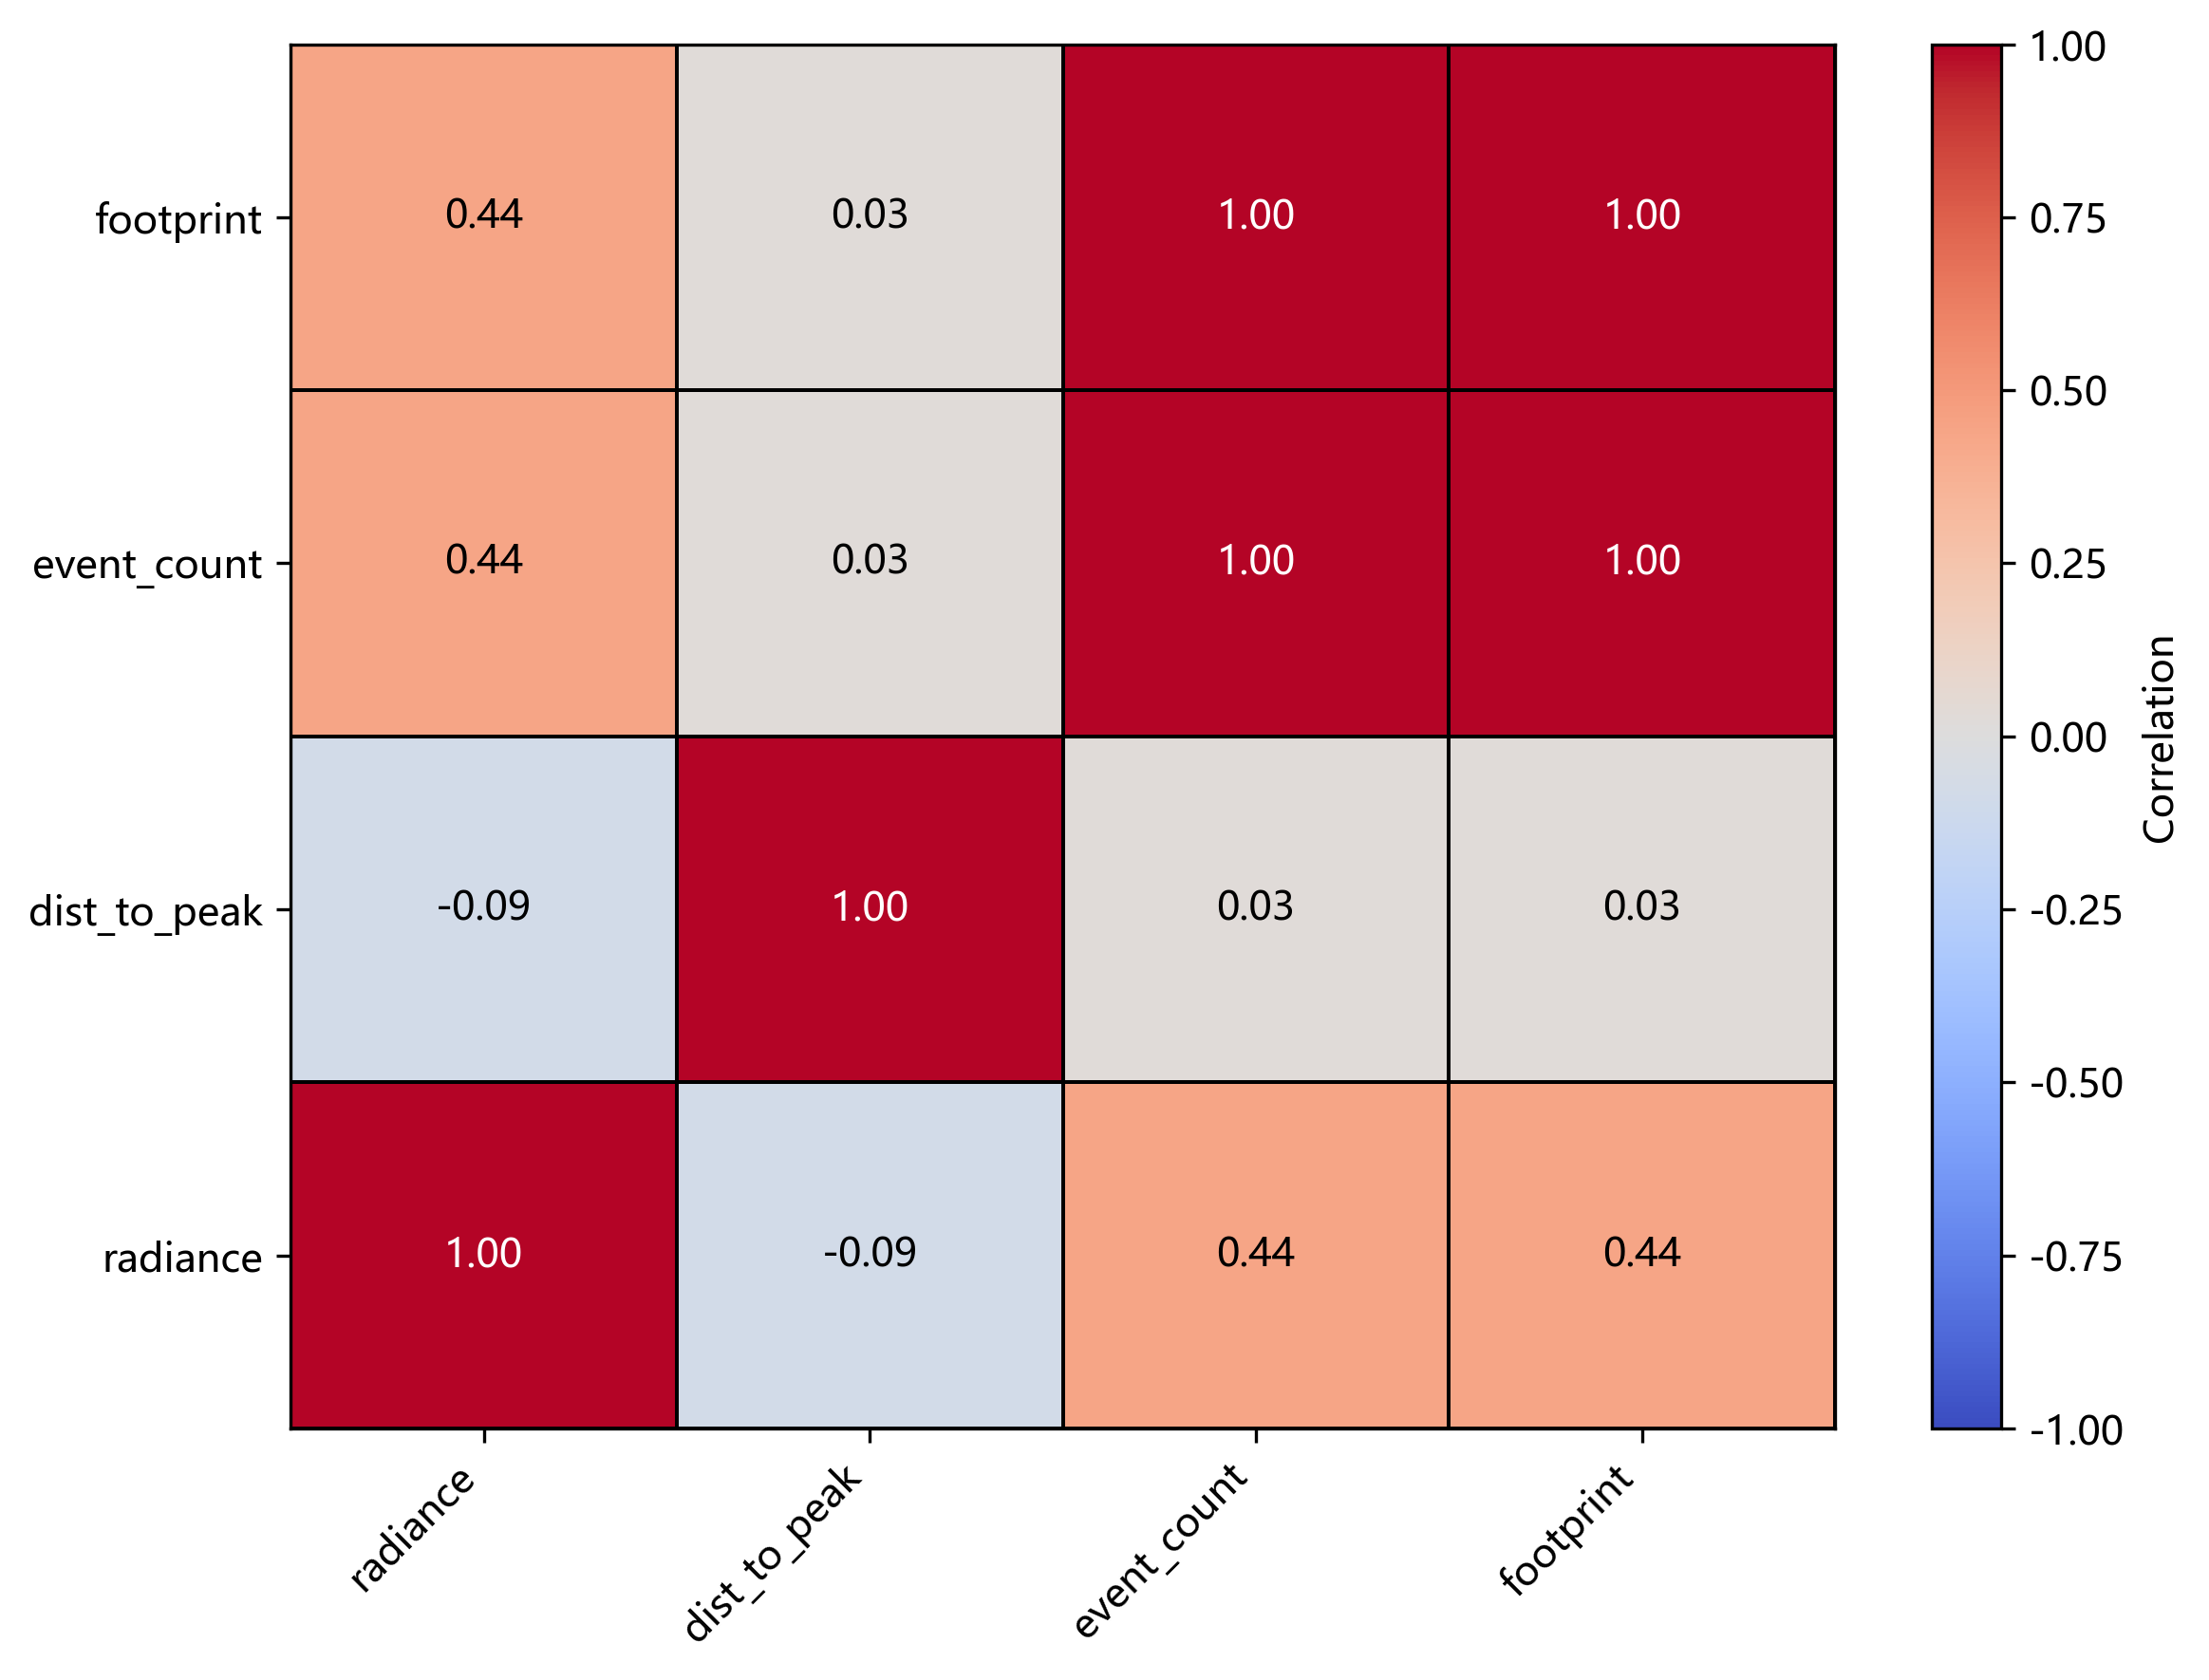

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300          # 默认 dpi
plt.rcParams['savefig.dpi'] = 300         # 保存时的 dpi（虽说不保存，但也设置）
plt.rcParams['savefig.bbox'] = 'tight'
# plt.rcParams['axes.facecolor'] = 'white'  # 坐标轴背景
plt.rcParams['figure.facecolor'] = 'white'  # 整个图窗背景
# plt.rcParams['axes.edgecolor'] = 'black'      # 坐标轴边框颜色
plt.rcParams['xtick.color'] = 'black'         # x轴刻度颜色
plt.rcParams['ytick.color'] = 'black'         # y轴刻度颜色

file_path = 'features_with_dist.parquet'
# file_path = 'preprocessed_features.parquet'
df = pd.read_parquet(file_path)
feature_cols = [
    'radiance', 'dist_to_peak',  'event_count',  'footprint'
    ]
corr = df[feature_cols].corr()
# 用 matplotlib 绘制热力图
fig, ax = plt.subplots(figsize=(8, 6))
ax.grid(False)  # 关闭网格线

# 绘制热力图
im = ax.pcolormesh(corr.values, cmap='coolwarm', vmin=-1, vmax=1,
                   edgecolors='black', linewidth=0.5)

# 设置刻度
ax.set_xticks(np.arange(len(feature_cols)) + 0.5)
ax.set_yticks(np.arange(len(feature_cols)) + 0.5)
ax.set_xticklabels(feature_cols, rotation=45, ha='right')
ax.set_yticklabels(feature_cols)

# 添加颜色条
plt.colorbar(im, ax=ax, label='Correlation')

# 在每个格子中显示数值
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        text = ax.text(j+0.5, i+.5, f'{corr.iloc[i, j]:.2f}',
                       ha="center", va="center",
                       color="white" if abs(corr.iloc[i, j]) > 0.5 else "black",
                       fontsize=10)

# 设置标题
# ax.set_title('Correlation Matrix of Features', fontsize=12)
plt.tight_layout()
plt.savefig('Variable correlation coefficient heatmap.pdf')
plt.show()

## 判断峰值时间

各小时平均代理风险:
hour
4.216667     444.308594
4.383333     435.924011
4.183333     432.429199
4.283333     431.709015
4.233333     428.399597
                ...    
19.083333     12.974500
19.233333     12.885400
19.350000     12.866700
19.183333     12.773100
18.983333     12.622000
Name: avg_energy_per_event, Length: 1426, dtype: float32

风险最高时段: 4.216666666666667 (风险值: 444.3086)


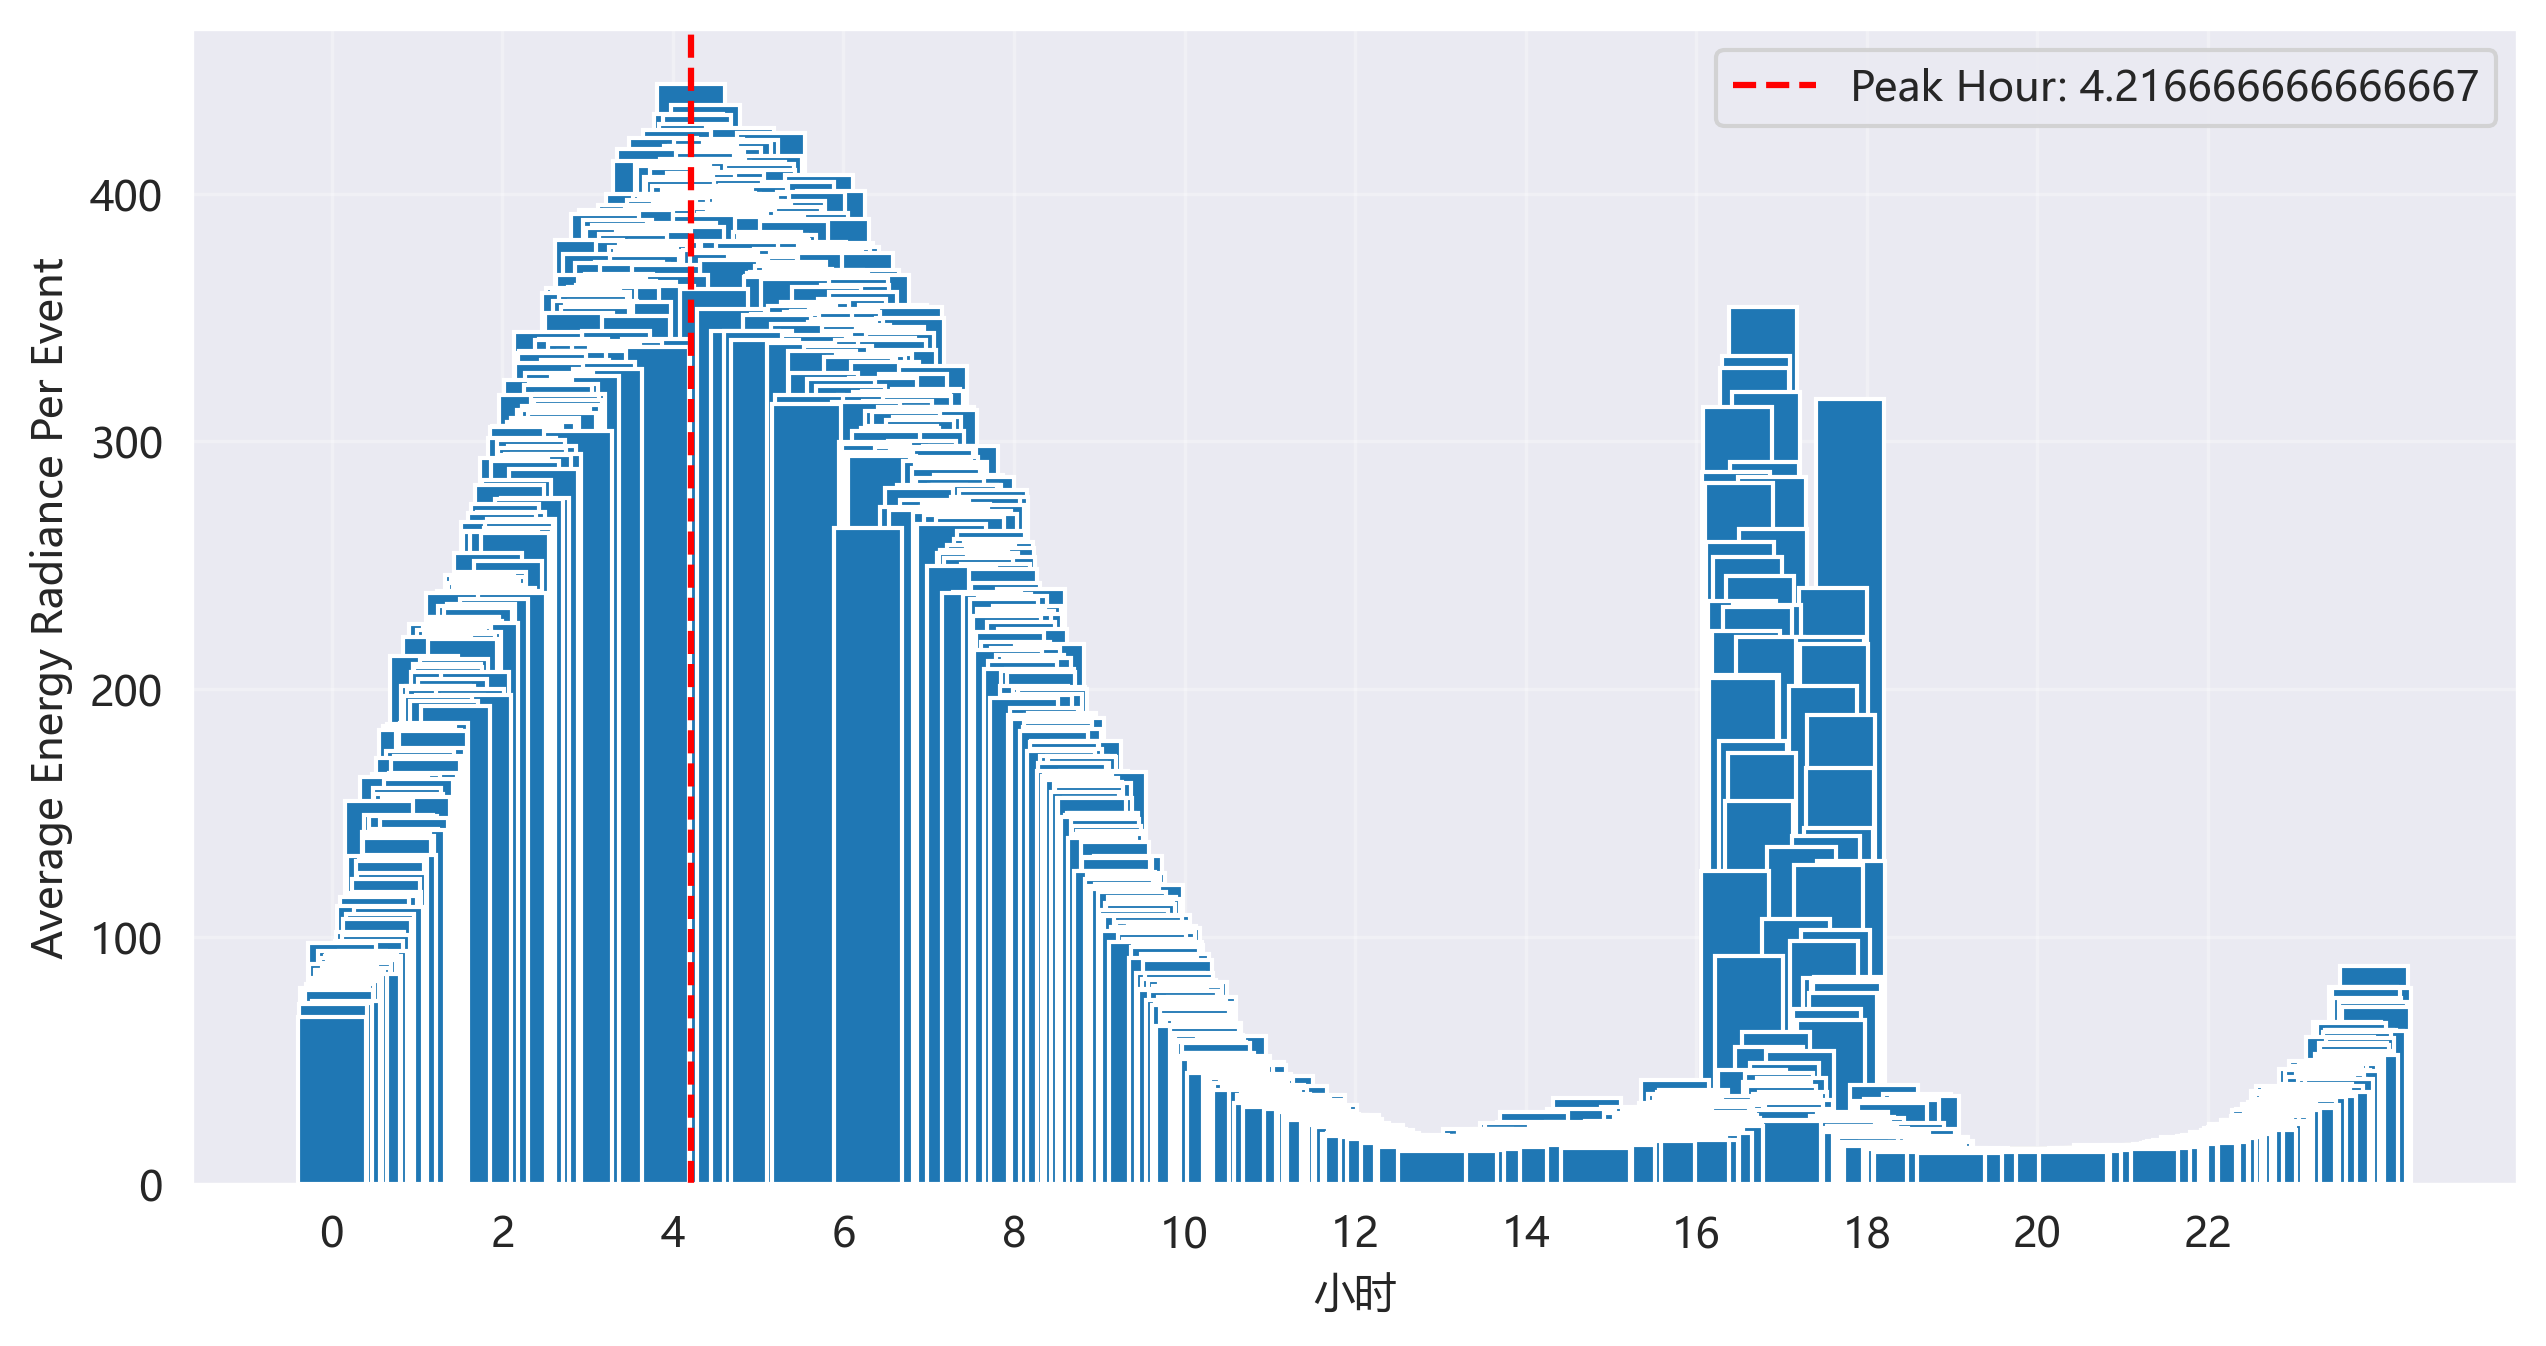

In [2]:
import pandas as pd
import numpy as np

# 读取数据
df = pd.read_parquet('preprocessed_features.parquet')

# 使用单事件能量密度
proxy_col = 'avg_energy_per_event'

# 按小时聚合风险均值
hourly_risk = df.groupby('hour')[proxy_col].mean().sort_values(ascending=False)

# 找出风险最高的小时
peak_hour = hourly_risk.idxmax()
peak_value = hourly_risk.max()

print("各小时平均代理风险:")
print(hourly_risk.round(4))
print(f"\n风险最高时段: {peak_hour} (风险值: {peak_value:.4f})")

# 可选：可视化
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300          # 默认 dpi
plt.rcParams['savefig.dpi'] = 300         # 保存时的 dpi（虽说不保存，但也设置）

plt.figure(figsize=(10, 5))
plt.bar(hourly_risk.index, hourly_risk.values)
plt.xlabel('小时')
plt.ylabel('Average Energy Radiance Per Event')
plt.title('')
plt.xticks(range(0, 24, 2))
plt.axvline(x=peak_hour, color='r', linestyle='--', label=f'Peak Hour: {peak_hour}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 论文专用（补插图）

各小时平均代理风险:
hour
4.216667     444.308594
4.383333     435.924011
4.183333     432.429199
4.283333     431.709015
4.233333     428.399597
                ...    
19.083333     12.974500
19.233333     12.885400
19.350000     12.866700
19.183333     12.773100
18.983333     12.622000
Name: avg_energy_per_event, Length: 1426, dtype: float32

风险最高时段: 4.216666666666667 (风险值: 444.3086)


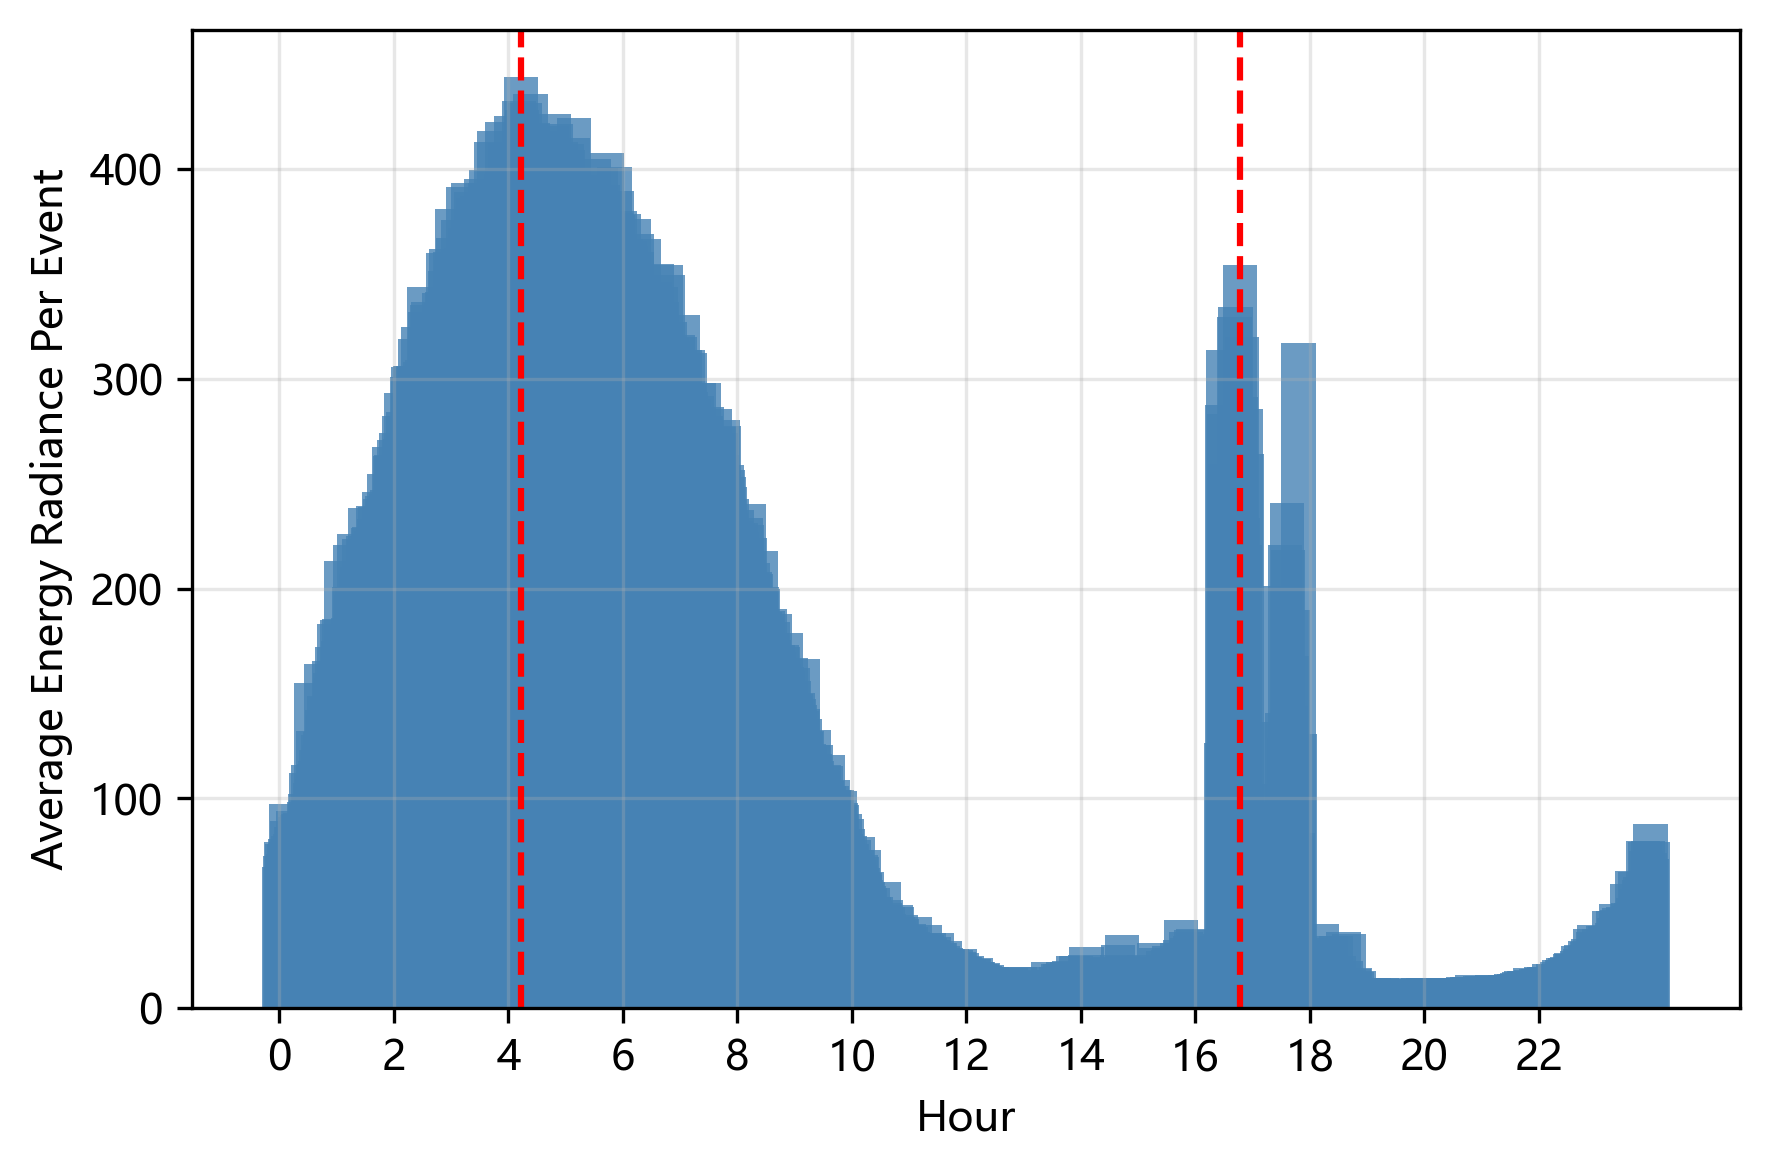

In [6]:
import pandas as pd
import numpy as np

# 读取数据
df = pd.read_parquet('preprocessed_features.parquet')

# 使用单事件能量密度
proxy_col = 'avg_energy_per_event'

# 按小时聚合风险均值
hourly_risk = df.groupby('hour')[proxy_col].mean().sort_values(ascending=False)

# 找出风险最高的小时
peak_hour = hourly_risk.idxmax()
peak_value = hourly_risk.max()

print("各小时平均代理风险:")
print(hourly_risk.round(4))
print(f"\n风险最高时段: {peak_hour} (风险值: {peak_value:.4f})")

# 可选：可视化
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300          # 默认 dpi
plt.rcParams['savefig.dpi'] = 300         # 保存时的 dpi（虽说不保存，但也设置）
plt.rcParams['savefig.bbox'] = 'tight'
# plt.rcParams['axes.facecolor'] = 'white'  # 坐标轴背景
plt.rcParams['figure.facecolor'] = 'white'  # 整个图窗背景
# plt.rcParams['axes.edgecolor'] = 'black'      # 坐标轴边框颜色
plt.rcParams['xtick.color'] = 'black'         # x轴刻度颜色
plt.rcParams['ytick.color'] = 'black'         # y轴刻度颜色
plt.rcParams.update({'font.size': 10})

plt.figure(figsize=(6, 4), facecolor='white')
plt.bar(hourly_risk.index, hourly_risk.values, width=0.6, alpha=0.8,
        color='steelblue', edgecolor='none', linewidth=0.5)
plt.xlabel('Hour')
plt.ylabel('Average Energy Radiance Per Event')
plt.title('')
plt.xticks(range(0, 24, 2))
plt.axvline(x=4.21, color='r', linestyle='--', label=f'Peak Hour')
plt.axvline(x=16.78, color='r', linestyle='--')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Daily statistics chart of radiation intensity by hour.pdf')
plt.show()

## 计算峰值距离时间

In [7]:
import pandas as pd
import numpy as np

# 读取数据
df = pd.read_parquet('preprocessed_features.parquet')

# 峰值时间设为2个时间
peak_time1 = 4.21
peak_time2 = 16.78

# 计算每个样本的时间
t = df['hour'].astype(float)

# 圆形距离（最小值）
diff1 = np.abs(t - peak_time1)
circ_dist1 = np.minimum(diff1, 24 - diff1)

diff2 = np.abs(t - peak_time2)
circ_dist2 = np.minimum(diff2, 24 - diff2)

circular_dist = np.minimum(circ_dist1, circ_dist2)

# 添加新特征
df['dist_to_peak'] = circular_dist

# 删除原来的 hour 列（不再使用）
# df = df.drop(columns=['hour'])

# 保存新文件
output_path = 'features_with_dist.parquet'
df.to_parquet(output_path, index=False)
print(f"已保存至 {output_path}")
print(f"新特征 dist_to_peak 描述性统计:\n{df['dist_to_peak'].describe()}")

已保存至 features_with_dist.parquet
新特征 dist_to_peak 描述性统计:
count    2.061226e+06
mean     3.191360e+00
std      1.759998e+00
min      3.333333e-03
25%      1.720000e+00
50%      3.286667e+00
75%      4.736667e+00
max      6.280000e+00
Name: dist_to_peak, dtype: float64


# 2.使用PCA提取第一主成分作为风险代理目标

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. 读取特征数据
features = pd.read_parquet('features_with_dist.parquet')

# 2. 确认要使用的特征列（排除非数值或已删除的列）
# 根据之前的特征工程，特征列包括：
# feature_cols = [
#     'radiance', 'footprint', 'event_count', 'hour', 'month',
#     'radiance_density', 'avg_energy_per_event',
#     'is_high_radiance', 'is_large_footprint', 'is_daytime', 'is_afternoon', 'is_intense'
# ]

feature_cols = [
    'radiance', 'event_count', 'dist_to_peak'
    ]
# 确保这些列都存在（若缺失则报错）
X = features[feature_cols].copy()

# 3. 标准化（PCA对方差敏感）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. PCA降维，提取第一和第二主成分
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(X_scaled)  # shape: (n_samples, 2)

# 5. 查看解释方差比例
print("=" * 50)
print("PCA 方差解释结果")
print("=" * 50)
print(f"第一主成分解释方差比例: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"第二主成分解释方差比例: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"前两个主成分累计解释方差比例: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")
print("=" * 50)

# 6. 特征载荷矩阵（每个主成分上各特征的权重）
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(2)],
    index=feature_cols
)
print("\n特征载荷矩阵（绝对值越大表示对该主成分贡献越大）:")
print(loadings.round(4))
print("\n各主成分上贡献最大的前3个特征:")
for pc in loadings.columns:
    top_features = loadings[pc].abs().sort_values(ascending=False).head(3)
    print(f"\n{pc}:")
    for feat, val in top_features.items():
        print(f"  {feat}: {val:.4f} (原始载荷: {loadings.loc[feat, pc]:+.4f})")

# 7. 构造代理目标（使用前两个主成分加权组合）
# 用方差贡献比例作为权重
weights = pca.explained_variance_ratio_  # [0.3225, 0.xxxx]
proxy_target_weighted = (pca_scores[:, 0] * weights[0] + pca_scores[:, 1] * weights[1]) / weights.sum()
# 等价于直接用第一主成分作为代理（传统方法）
proxy_target_pc1 = pca_scores[:, 0]

# 8. 添加到DataFrame
features['proxy_risk_pc1'] = proxy_target_pc1
features['proxy_risk_weighted'] = proxy_target_weighted

PCA 方差解释结果
第一主成分解释方差比例: 0.4817 (48.17%)
第二主成分解释方差比例: 0.3368 (33.68%)
前两个主成分累计解释方差比例: 0.8185 (81.85%)

特征载荷矩阵（绝对值越大表示对该主成分贡献越大）:
                 PC1     PC2
radiance      0.7100 -0.0568
event_count   0.6980  0.1896
dist_to_peak -0.0938  0.9802

各主成分上贡献最大的前3个特征:

PC1:
  radiance: 0.7100 (原始载荷: +0.7100)
  event_count: 0.6980 (原始载荷: +0.6980)
  dist_to_peak: 0.0938 (原始载荷: -0.0938)

PC2:
  dist_to_peak: 0.9802 (原始载荷: +0.9802)
  event_count: 0.1896 (原始载荷: +0.1896)
  radiance: 0.0568 (原始载荷: -0.0568)


In [15]:
# 9. 保存
features.to_parquet('features_with_proxy.parquet', index=False)
print("代理目标已添加并保存至 features_with_proxy.parquet")

代理目标已添加并保存至 features_with_proxy.parquet


# 3.随机森林训练

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
import joblib

# ==================== 1. 读取数据 ====================
df = pd.read_parquet('features_with_proxy.parquet')

# ==================== 2. 定义特征和目标 ====================
# 特征列：原始特征（不包括任何代理目标列和可能的非数值列）
feature_cols = [
    'radiance', 'dist_to_peak',  'event_count',
    ]
# 确保所有特征列都存在
X = df[feature_cols].copy()
# 选择代理目标（可切换：'proxy_risk_weighted' 或 'proxy_risk_pc1'）
target_col = 'proxy_risk_weighted'  # 累计解释方差约50%，更稳健
y = df[target_col].copy()

print(f"特征矩阵形状: {X.shape}")
print(f"目标变量描述:\n{y.describe()}")

# ==================== 3. 划分训练集和测试集 ====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==================== 4. 基础随机森林（初步评估） ====================
# 将连续目标划分为10个等频区间（每层样本数大致相等）
y_train_binned = pd.qcut(y_train, q=10, labels=False, duplicates='drop')
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train,
    train_size=0.05,          # 使用 5% 子集
    random_state=42,
    stratify=y_train_binned   # 分层抽取4%的数据训练
)
print(f"训练集大小: {X_train_sub.shape[0]}, 测试集大小: {X_test.shape[0]}")
# rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2)
# rf_base.fit(X_train_sub, y_train_sub)
# base_score = rf_base.score(X_test, y_test)
# print(f"基础模型 R² (测试集): {base_score:.20f}")
# ==================== 5. 交叉验证调参 ====================
# # 从训练集中随机抽取 10% 样本（约 16.5 万条）
# X_train_sub, _, y_train_sub, _ = train_test_split(
#     X_train, y_train,
#     train_size=0.1,          # 使用 10% 子集
#     random_state=42,
#     stratify=None            # 回归任务无需分层
# )
#
# print(f"子集大小: {X_train_sub.shape[0]} (原训练集 {X_train.shape[0]})")

# 参数网格（可根据需要调整范围）
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [20, None]
}

rf = RandomForestRegressor(random_state=42, n_jobs=2)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,               # 5折交叉验证
    scoring='r2',
    n_jobs=2,
    verbose=1
)

X_train_sub_array = X_train_sub.values
y_train_sub_array = y_train_sub.values
grid_search.fit(X_train_sub_array, y_train_sub_array) # 使用子集拟合

print(f"最佳参数: {grid_search.best_params_}")
print(f"子集上最佳交叉验证 R²: {grid_search.best_score_:.20f}")

'''
搜索参数后，使用最佳参数在训练集上重新训练
'''

best_params = grid_search.best_params_
best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=2)
best_rf.fit(X_train_sub, y_train_sub)              # 全量训练

# 评估测试集
test_score = best_rf.score(X_test, y_test)
print(f"全量模型测试集 R²: {test_score:.20f}")   # 高精度显示

# ==================== 6. 提取特征重要性并归一化为权重 ====================
feature_importances = best_rf.feature_importances_

# 归一化到 [0,1] 且和为 1
# scaler = MinMaxScaler()
# importance_normalized = scaler.fit_transform(feature_importances.reshape(-1, 1)).flatten()
# weights = importance_normalized / importance_normalized.sum()  # 确保和为1
weights = feature_importances / feature_importances.sum()

# 构建权重DataFrame
weight_df = pd.DataFrame({
    'feature': feature_cols,
    # 'importance_raw': feature_importances,
    # 'importance_normalized': importance_normalized,
    'weight': weights
}).sort_values('weight', ascending=False)

print("\n特征权重（归一化后）:")
print(weight_df.round(4))

特征矩阵形状: (2061226, 3)
目标变量描述:
count    2.061226e+06
mean     3.529917e-18
std      8.194995e-01
min     -1.082589e+00
25%     -4.985881e-01
50%     -1.294420e-01
75%      2.168120e-01
max      2.058392e+01
Name: proxy_risk_weighted, dtype: float64
训练集大小: 82449, 测试集大小: 412246
Fitting 5 folds for each of 4 candidates, totalling 20 fits
最佳参数: {'max_depth': 20, 'n_estimators': 100}
子集上最佳交叉验证 R²: 0.99926122033954778434
全量模型测试集 R²: 0.99923580441497095173

特征权重（归一化后）:
        feature  weight
2   event_count  0.6019
0      radiance  0.2276
1  dist_to_peak  0.1705


## 保存模型与权重

In [5]:
joblib.dump(best_rf, 'random_forest_risk_model.pkl')
# weight_df.to_csv('feature_weights.csv', index=False)
print("\n模型已保存至 random_forest_risk_model.pkl")
# print("权重已保存至 feature_weights.csv")


模型已保存至 random_forest_risk_model.pkl


## SHAP值计算

In [6]:
import shap
import joblib

reload = 0 # 是否重新加载模型
if reload:    # 加载随机森林模型
    best_rf = joblib.load('random_forest_risk_model.pkl')

# 加载特征数据（确保与训练时使用的特征列一致）
df = pd.read_parquet('features_with_proxy.parquet')

# 定义特征列（必须与训练时完全一致！！）
feature_cols = [
    'radiance', 'dist_to_peak',  'event_count',
    ]

X = df[feature_cols].copy()

# 为避免内存爆炸，从训练子集中随机抽取指定个样本用于SHAP解释
sample_size = min(800, X_train_sub.shape[0])
X_sample = X_train_sub.sample(n=sample_size, random_state=42)

# 创建TreeExplainer并计算SHAP值
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_sample)
joblib.dump(X_sample, 'X_sample.pkl')

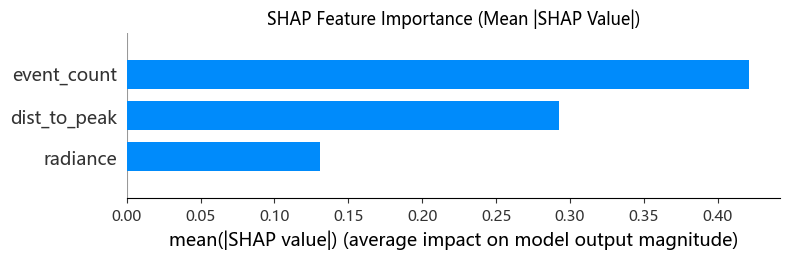

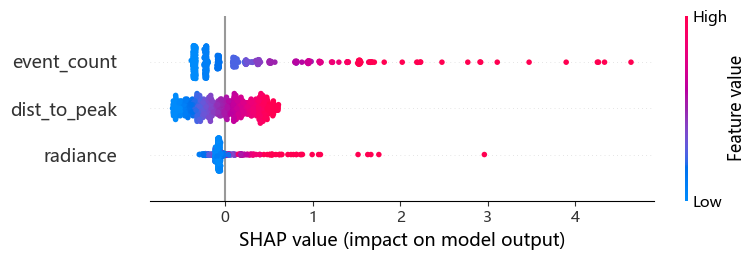

SHAP分析完成，图表已保存。


In [8]:
reload = 1
if reload:
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
    plt.rcParams['axes.unicode_minus'] = False
# 1. 特征重要性条形图（SHAP平均绝对值）
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP Value|)")
plt.tight_layout()
plt.savefig("shap_feature_importance.pdf", dpi=300)
plt.show()

# 2. 详细summary图（同时显示特征值大小对SHAP的影响）
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, show=False)
plt.savefig("shap_summary_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()

# 3. 可选：单个依赖图（例如对最重要的特征radiance_density）
# shap.dependence_plot("radiance_density", shap_values, X_sample, feature_names=feature_cols)

# # 4. 保存SHAP值（可选）

joblib.dump(shap_values, "shap_values_sample.pkl")
print("SHAP分析完成，图表已保存。")

## 保存SHAP值数据

In [20]:
# # 在现有代码末尾添加以下保存代码
# import pandas as pd

# 1. 全局特征重要性数据（条形图用）
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

# 保存为CSV
importance_df.to_csv('shap_importance.csv', index=False)

# 2. 详细SHAP值矩阵（蜂群图/散点图用）
# 每一行是一个样本，每一列是一个特征
shap_df = pd.DataFrame(shap_values, columns=feature_cols)
# 同时保存对应的特征值
X_sample_reset = X_sample.reset_index(drop=True)
shap_df.to_csv('shap_values_matrix.csv', index=False)
X_sample_reset.to_csv('shap_feature_values.csv', index=False)

# 3. （可选）单个特征的SHAP依赖图数据
# 以最重要的特征为例
top_feature = importance_df.iloc[0]['feature']
dependence_df = pd.DataFrame({
    'feature_value': X_sample_reset[top_feature],
    'shap_value': shap_df[top_feature]
})
dependence_df.to_csv(f'shap_dependence_{top_feature}.csv', index=False)

print("SHAP数据已保存为CSV文件，可用于Excel/PPT重绘。")

SHAP数据已保存为CSV文件，可用于Excel/PPT重绘。
